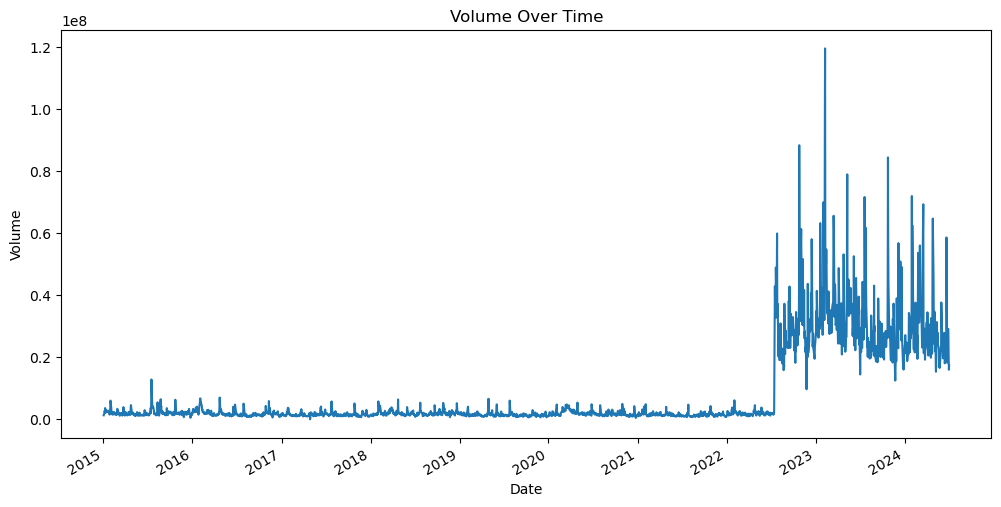

/Users/anbschool0012/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


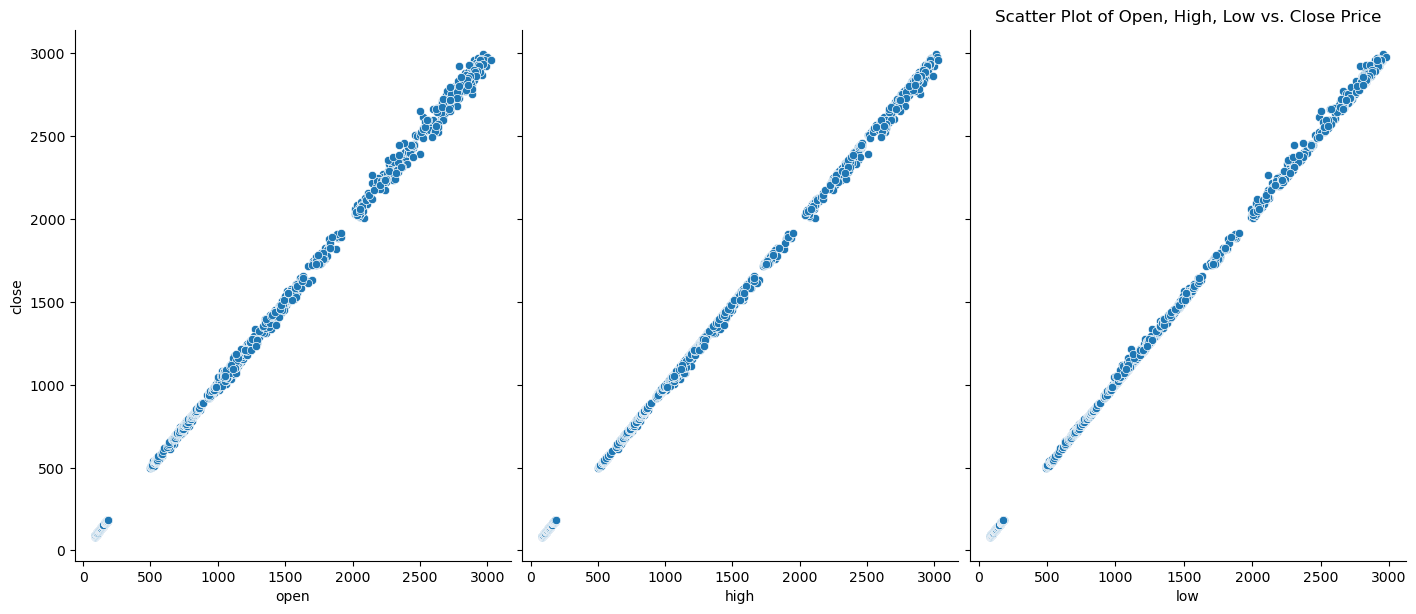

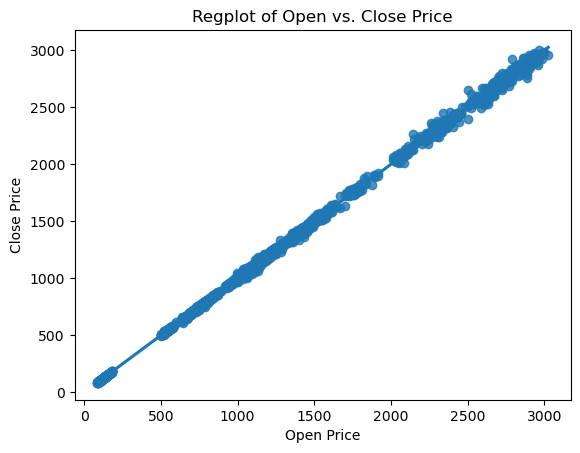

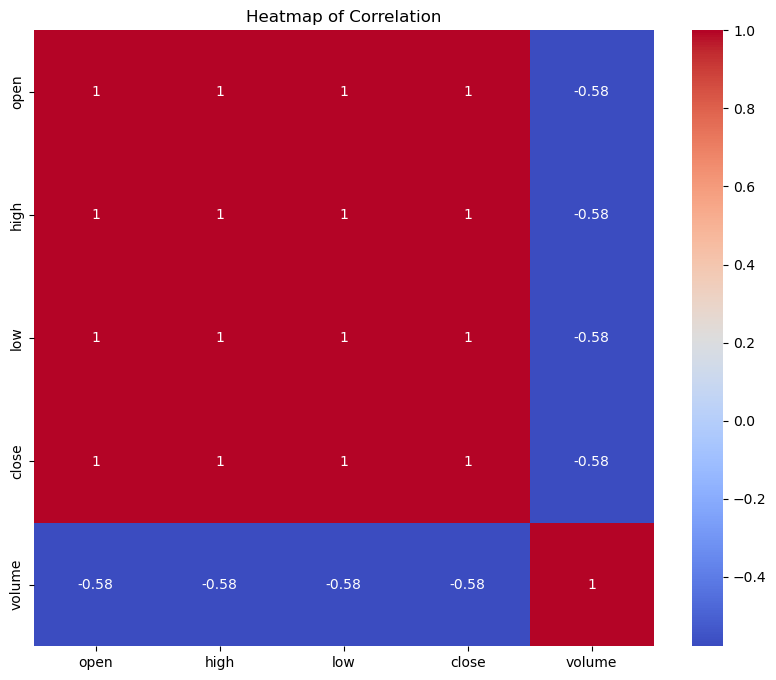

/var/folders/1t/2c88cpvx50s6j4zn29nz2y580000gn/T/ipykernel_1100/4242801204.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rolling_mean'] = df['volume'].rolling(window=window).mean()


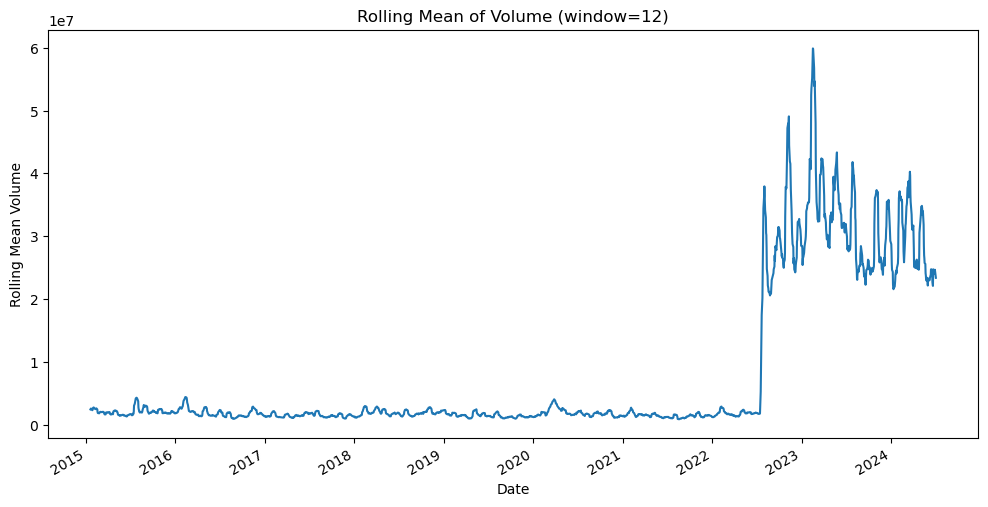

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
Google_Data = pd.read_csv('./data/Google_Stock_Price.csv')

# Convert the timestamp to datetime dtype
Google_Data['timestamp'] = pd.to_datetime(Google_Data['timestamp'])

# Rename the timestamp column to Date
Google_Data.rename(columns={'timestamp': 'Date'}, inplace=True)
Google_Data.set_index('Date', inplace=True)

# Filter data from 2015-01-01 to 2024-07-02
df = Google_Data.loc['2015-01-01':'2024-07-02']

# Plot the volume data
plt.figure(figsize=(12, 6))
df['volume'].plot()
plt.title('Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

# Calculate correlation
correlation = df.corr()

# Store the value of open, high, low in x variable, and close in y variable
x = df[['open', 'high', 'low']]
y = df['close']

# Scatter plot
sns.pairplot(df, x_vars=['open', 'high', 'low'], y_vars='close', height=6, aspect=0.8, kind='scatter')
plt.title('Scatter Plot of Open, High, Low vs. Close Price')
plt.show()

# Showing regplot for correlation between 'open' and 'close'
sns.regplot(x=df['open'], y=y)
plt.title('Regplot of Open vs. Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.show()

# Showing correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Heatmap of Correlation')
plt.show()

# Calculate rolling mean
window = 12
df['rolling_mean'] = df['volume'].rolling(window=window).mean()

# Plot rolling mean of volume
plt.figure(figsize=(12, 6))
df['rolling_mean'].plot()
plt.title(f'Rolling Mean of Volume (window={window})')
plt.xlabel('Date')
plt.ylabel('Rolling Mean Volume')
plt.show()


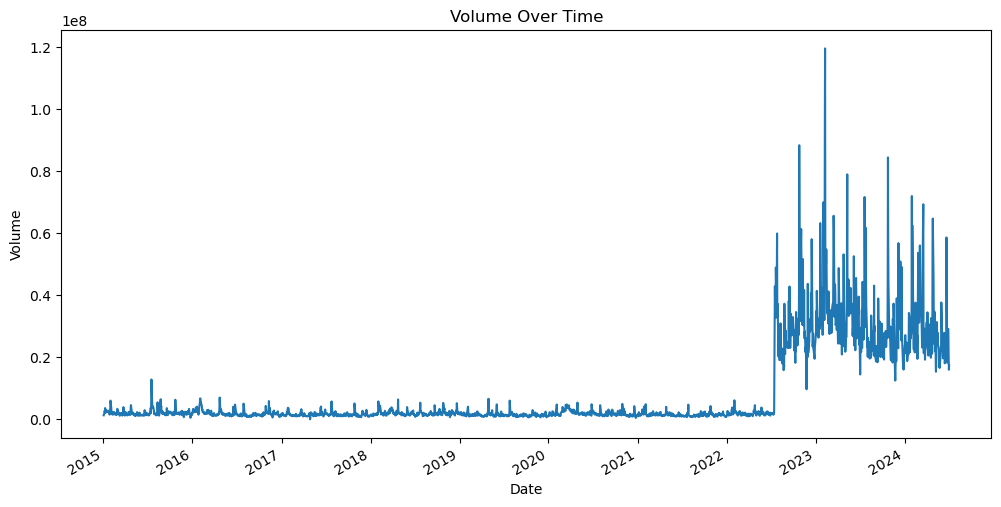

/Users/anbschool0012/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


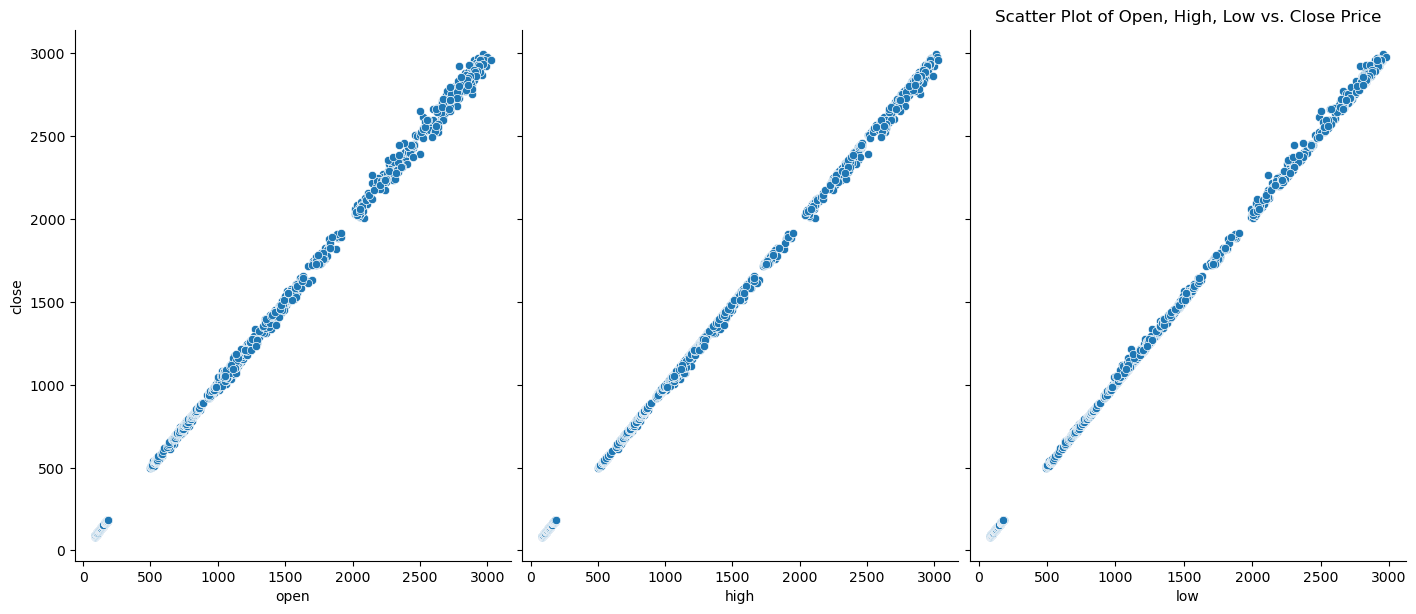

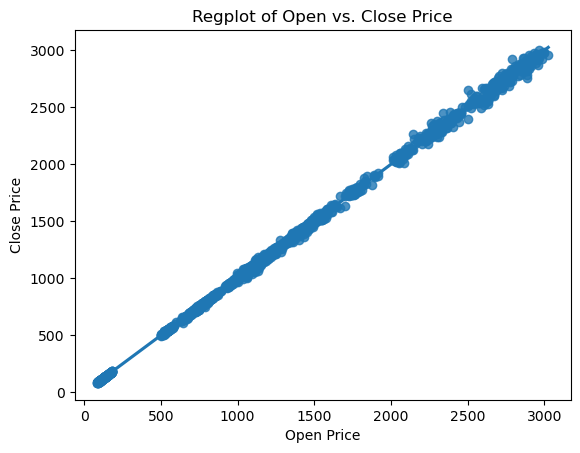

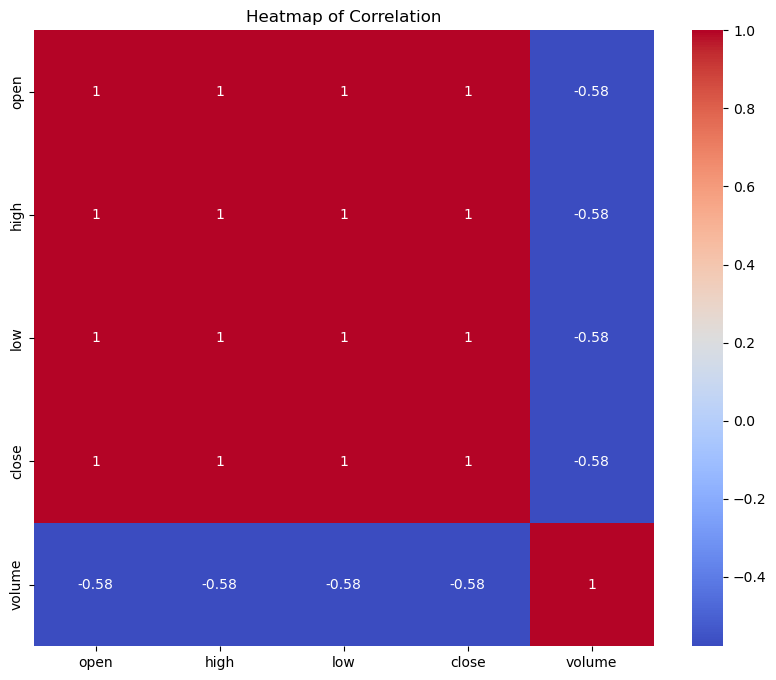

/var/folders/1t/2c88cpvx50s6j4zn29nz2y580000gn/T/ipykernel_1100/4269301940.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rolling_mean'] = df['volume'].rolling(window=window).mean()


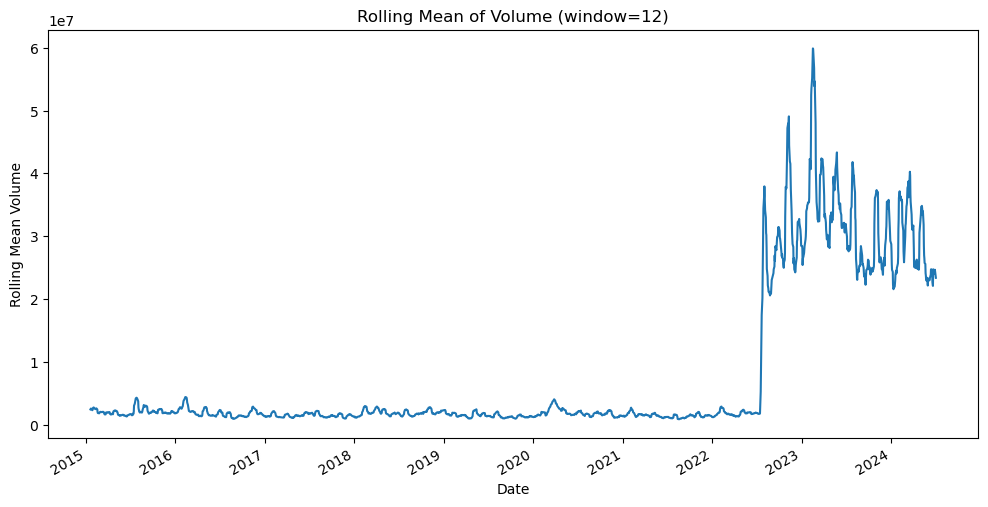

/var/folders/1t/2c88cpvx50s6j4zn29nz2y580000gn/T/ipykernel_1100/4269301940.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time'] = np.arange(len(df))


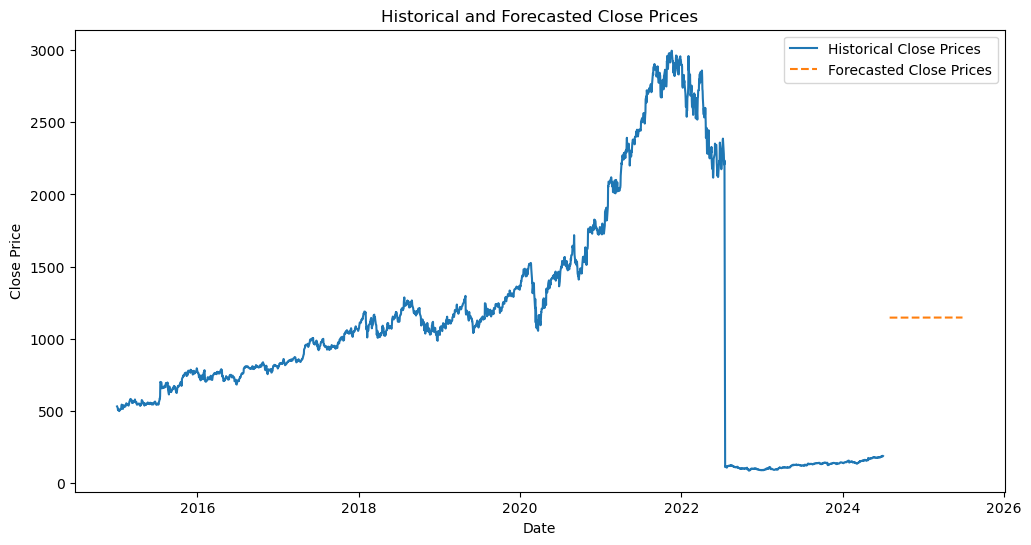

         Date  Forecasted_Close
0  2024-08-01       1145.397957
1  2024-08-31       1145.458302
2  2024-09-30       1145.518647
3  2024-10-30       1145.578992
4  2024-11-29       1145.639337
5  2024-12-29       1145.699682
6  2025-01-28       1145.760028
7  2025-02-27       1145.820373
8  2025-03-29       1145.880718
9  2025-04-28       1145.941063
10 2025-05-28       1146.001408
11 2025-06-27       1146.061753


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta

# Load the data
Google_Data = pd.read_csv('./data/Google_Stock_Price.csv')

# Convert the timestamp to datetime dtype
Google_Data['timestamp'] = pd.to_datetime(Google_Data['timestamp'])

# Rename the timestamp column to Date
Google_Data.rename(columns={'timestamp': 'Date'}, inplace=True)
Google_Data.set_index('Date', inplace=True)

# Filter data from 2015-01-01 to 2024-07-02
df = Google_Data.loc['2015-01-01':'2024-07-02']

# Plot the volume data
plt.figure(figsize=(12, 6))
df['volume'].plot()
plt.title('Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

# Calculate correlation
correlation = df.corr()

# Store the value of open, high, low in x variable, and close in y variable
x = df[['open', 'high', 'low']]
y = df['close']

# Scatter plot
sns.pairplot(df, x_vars=['open', 'high', 'low'], y_vars='close', height=6, aspect=0.8, kind='scatter')
plt.title('Scatter Plot of Open, High, Low vs. Close Price')
plt.show()

# Showing regplot for correlation between 'open' and 'close'
sns.regplot(x=df['open'], y=y)
plt.title('Regplot of Open vs. Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.show()

# Showing correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Heatmap of Correlation')
plt.show()

# Calculate rolling mean
window = 12
df['rolling_mean'] = df['volume'].rolling(window=window).mean()

# Plot rolling mean of volume
plt.figure(figsize=(12, 6))
df['rolling_mean'].plot()
plt.title(f'Rolling Mean of Volume (window={window})')
plt.xlabel('Date')
plt.ylabel('Rolling Mean Volume')
plt.show()

# Forecasting the next 12 months using linear regression
# Creating a time variable
df['time'] = np.arange(len(df))

# Linear regression
A = np.vstack([df['time'], np.ones(len(df['time']))]).T
m, c = np.linalg.lstsq(A, df['close'], rcond=None)[0]

# Predict the next 12 months
last_time = df['time'].iloc[-1]
future_times = np.arange(last_time + 1, last_time + 1 + 12)
future_dates = [df.index[-1] + timedelta(days=30*i) for i in range(1, 13)]
future_close = m * future_times + c

# Plot the historical and forecasted values
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['close'], label='Historical Close Prices')
plt.plot(future_dates, future_close, label='Forecasted Close Prices', linestyle='--')
plt.title('Historical and Forecasted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Showing the forecasted close prices
forecasted_df = pd.DataFrame({'Date': future_dates, 'Forecasted_Close': future_close})
print(forecasted_df)


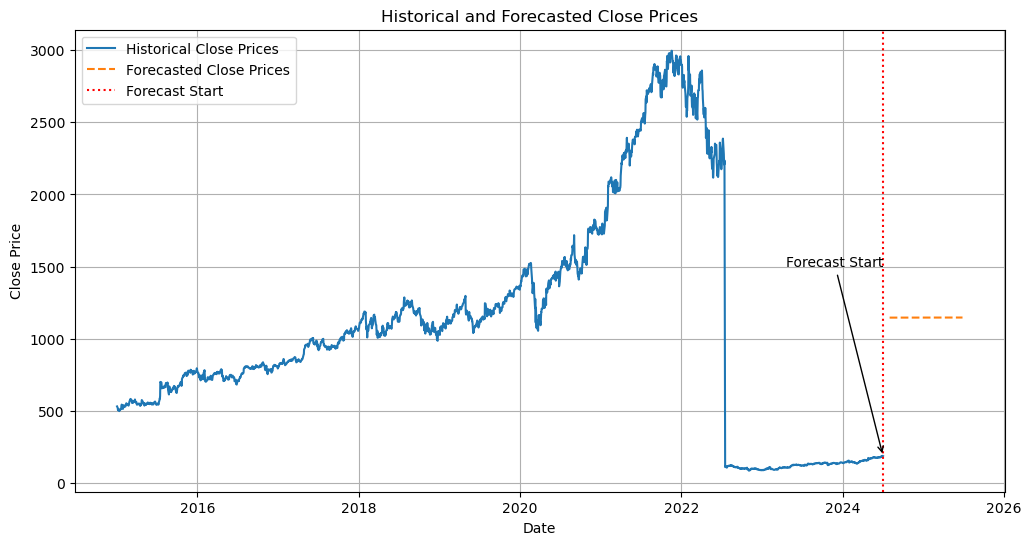

         Date  Forecasted_Close
0  2024-08-01       1145.397957
1  2024-08-31       1145.458302
2  2024-09-30       1145.518647
3  2024-10-30       1145.578992
4  2024-11-29       1145.639337
5  2024-12-29       1145.699682
6  2025-01-28       1145.760028
7  2025-02-27       1145.820373
8  2025-03-29       1145.880718
9  2025-04-28       1145.941063
10 2025-05-28       1146.001408
11 2025-06-27       1146.061753


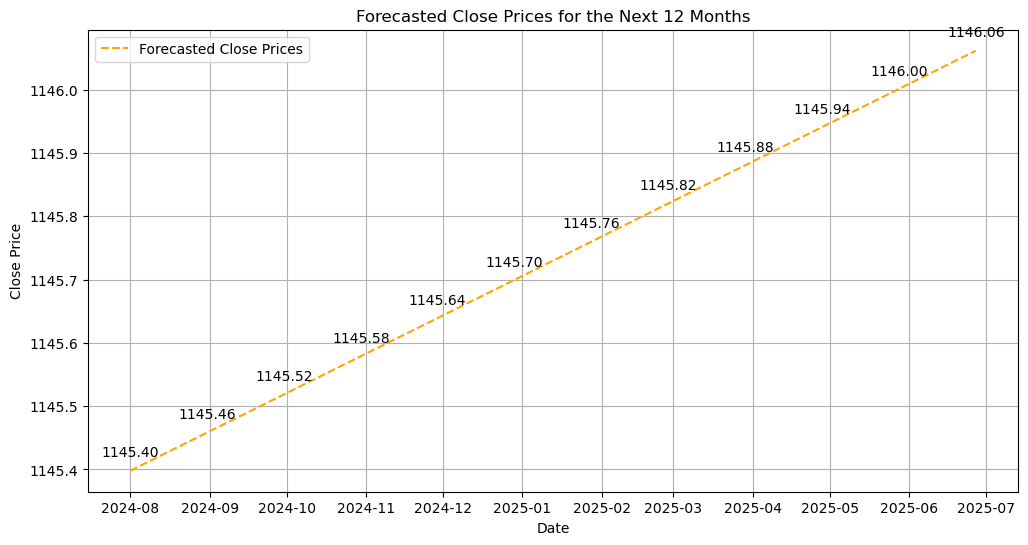

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta

# Load the data
Google_Data = pd.read_csv('./data/Google_Stock_Price.csv')

# Convert the timestamp to datetime dtype
Google_Data['timestamp'] = pd.to_datetime(Google_Data['timestamp'])

# Rename the timestamp column to Date
Google_Data.rename(columns={'timestamp': 'Date'}, inplace=True)
Google_Data.set_index('Date', inplace=True)

# Filter data from 2015-01-01 to 2024-07-02
df = Google_Data.loc['2015-01-01':'2024-07-02'].copy()

# Create a time variable for the linear regression
df['time'] = np.arange(len(df))

# Linear regression
A = np.vstack([df['time'], np.ones(len(df['time']))]).T
m, c = np.linalg.lstsq(A, df['close'], rcond=None)[0]

# Predict the next 12 months
last_time = df['time'].iloc[-1]
future_times = np.arange(last_time + 1, last_time + 1 + 12)
future_dates = [df.index[-1] + timedelta(days=30*i) for i in range(1, 13)]
future_close = m * future_times + c

# Plot the historical and forecasted values with enhanced details
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['close'], label='Historical Close Prices')
plt.plot(future_dates, future_close, label='Forecasted Close Prices', linestyle='--')
plt.axvline(df.index[-1], color='red', linestyle=':', label='Forecast Start')
plt.title('Historical and Forecasted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)

# Annotate the start of the forecast
plt.annotate('Forecast Start', xy=(df.index[-1], df['close'].iloc[-1]), xytext=(df.index[-1], df['close'].max()/2),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             horizontalalignment='right')

# Show the plot
plt.show()

# Showing the forecasted close prices with a detailed table
forecasted_df = pd.DataFrame({'Date': future_dates, 'Forecasted_Close': future_close})
print(forecasted_df)

# Zoom in to the forecast period
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_close, label='Forecasted Close Prices', linestyle='--', color='orange')
plt.title('Forecasted Close Prices for the Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)

# Annotate forecasted points
for i, txt in enumerate(future_close):
    plt.annotate(f'{txt:.2f}', (future_dates[i], future_close[i]), textcoords="offset points", xytext=(0, 10), ha='center')

# Show the zoomed-in plot
plt.show()


In [4]:
# Import the necessary libraries
import pandas as pd  # For data manipulation and analysis
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns  # For statistical data visualization (not used in this code, but imported)
import numpy as np  # For numerical operations
from datetime import datetime, timedelta  # For working with dates and times

# Load the data from a CSV file into a DataFrame
Google_Data = pd.read_csv('./data/Google_Stock_Price.csv')  # Reads the CSV file and loads it into the DataFrame 'Google_Data'

# Convert the 'timestamp' column to datetime data type for proper date operations
Google_Data['timestamp'] = pd.to_datetime(Google_Data['timestamp'])  # Converts the 'timestamp' column from string to datetime objects

# Rename the 'timestamp' column to 'Date' for clarity and easier reference
Google_Data.rename(columns={'timestamp': 'Date'}, inplace=True)  # Renames the 'timestamp' column to 'Date' in place (no new DataFrame created)
Google_Data.set_index('Date', inplace=True)  # Sets the 'Date' column as the index of the DataFrame

# Filter the data to include only entries from 2015-01-01 to 2024-07-02
df = Google_Data.loc['2015-01-01':'2024-07-02'].copy()  # Slices the DataFrame to include only the specified date range and creates a copy of the data

# Create a 'time' variable for use in linear regression
df['time'] = np.arange(len(df))  # Creates a 'time' variable starting from 0 up to the length of the DataFrame (used as the independent variable in regression)

# Perform linear regression to find the trend in the closing prices
A = np.vstack([df['time'], np.ones(len(df['time']))]).T  # Constructs the matrix A for the linear regression: [time, 1]
m, c = np.linalg.lstsq(A, df['close'], rcond=None)[0]  # Performs least-squares regression to fit the model close = m*time + c

# Predict the close prices for the next 12 months
last_time = df['time'].iloc[-1]  # Gets the last time value from the existing data
future_times = np.arange(last_time + 1, last_time + 1 + 12)  # Generates future time points for the next 12 months
future_dates = [df.index[-1] + timedelta(days=30*i) for i in range(1, 13)]  # Generates future dates, approximately 30 days apart
future_close = m * future_times + c  # Calculates the predicted close prices for the future time points

# Calculate the 30-day rolling mean of the close prices
window =      # Defines the window size for the rolling mean
df['rolling_mean'] = df['close'].rolling(window=window).mean()  # Calculates the rolling mean with a 30-day window and adds it as a new column to the DataFrame

# Plot the historical data, rolling mean, and forecasted values
plt.figure(figsize=(12, 6))  # Creates a new figure with a specified size for the plot
plt.plot(df.index, df['close'], label='Historical Close Prices')  # Plots the historical close prices
plt.plot(df.index, df['rolling_mean'], label=f'Rolling Mean ({window} days)', linestyle='--', color='green')  # Plots the rolling mean with a dashed line in green
plt.plot(future_dates, future_close, label='Forecasted Close Prices', linestyle='--', color='orange')  # Plots the forecasted close prices with a dashed line in orange
plt.axvline(df.index[-1], color='red', linestyle=':', label='Forecast Start')  # Adds a vertical line at the start of the forecast period with a dotted line in red
plt.title('Historical, Rolling Mean, and Forecasted Close Prices')  # Sets the title of the plot
plt.xlabel('Date')  # Labels the x-axis
plt.ylabel('Close Price')  # Labels the y-axis
plt.legend()  # Displays the legend for the plot
plt.grid(True)  # Enables the grid on the plot for better readability

# Annotate the start of the forecast period
plt.annotate('Forecast Start', xy=(df.index[-1], df['close'].iloc[-1]), xytext=(df.index[-1], df['close'].max()/2),
             arrowprops=dict(facecolor='black', arrowstyle='->'),  # Creates an arrow annotation pointing to the start of the forecast
             horizontalalignment='right')  # Aligns the text to the right of the arrow

# Show the plot
plt.show()  # Displays the plot

# Create and print a DataFrame with the forecasted close prices
forecasted_df = pd.DataFrame({'Date': future_dates, 'Forecasted_Close': future_close})  # Creates a new DataFrame with future dates and corresponding forecasted close prices
print(forecasted_df)  # Prints the DataFrame containing the forecasted values

# Plot the forecasted close prices
plt.figure(figsize=(12, 6))  # Creates a new figure for the zoomed-in plot
plt.plot(future_dates, future_close, label='Forecasted Close Prices', linestyle='--', color='orange')  # Plots the forecasted close prices for the next 12 months
plt.title('Forecasted Close Prices for the Next 12 Months')  # Sets the title of the plot
plt.xlabel('Date')  # Labels the x-axis
plt.ylabel('Close Price')  # Labels the y-axis
plt.legend()  # Displays the legend for the plot
plt.grid(True)  # Enables the grid on the plot for better readability

# Annotate the forecasted points with their values
for i, txt in enumerate(future_close):  # Loops through each forecasted value and its index
    plt.annotate(f'{txt:.2f}', (future_dates[i], future_close[i]), textcoords="offset points", xytext=(0, 10), ha='center')  # Adds text annotations for each forecasted value

# Show the zoomed-in plot
plt.show()  # Displays the zoomed-in plot


SyntaxError: invalid syntax (1935696810.py, line 35)